In [142]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import os
RESULTS_DIR = os.getcwd() + "/../results/H/safe_risky4/"
RESULTS_DIR

'/Users/angel/Desktop/prism-games/prism-examples/csgs/learning/analysis/../results/H/safe_risky4/'

In [211]:
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "lines.linewidth": 2,
})

# optional LaTeX (if installed)
plt.rcParams["text.usetex"] = True

In [212]:
fpath = Path(RESULTS_DIR) / "cleaned.csv"
print(fpath)
res_df = pd.read_csv(fpath)

/Users/angel/Desktop/prism-games/prism-examples/csgs/learning/analysis/../results/H/safe_risky4/cleaned.csv


In [213]:
# --- Basic cleaning ---
res_df = res_df.rename(columns={
    "time_mean (s)": "time",
    "time_std (s)": "time_std",
    "episodes_mean": "episodes",
    "samples_mean": "samples"
})

cols = ["H", "episodes", "episodes_std", "time", "time_std", "samples", "samples_std"]
res_df = res_df.loc[:, cols]
res_df = res_df.sort_values("H")
for c in cols:
    res_df[c] = pd.to_numeric(res_df[c], errors="coerce")
res_df = res_df[res_df['H'] < 11]

res_df = (
    res_df.replace(["#DIV/0!", ""], np.nan)  # Excel errors + empty strings
      .replace(r'^\s*$', np.nan, regex=True)  # whitespace
      .fillna(0)
)
res_df

,H,episodes,episodes_std,time,time_std,samples,samples_std
0,1,3.676667e+02,3.055050,0.409262,0.022405,2.009333e+04,192.032115
1,3,9.016567e+04,35.529331,120.669580,1.071388,1.161419e+07,3451.719040
2,5,3.333347e+05,5479.044199,861.516829,9.997969,5.009203e+07,8420.942722
3,7,7.346410e+05,398.060297,3223.123906,18.693050,1.373585e+08,122326.853500
4,9,1.444160e+06,310079.303100,9122.241143,324.013675,2.952152e+08,299168.179100


## Data cleaning only

In [205]:
H_LOGS_DIR = os.getcwd() + "/../logs/H/safe_risky4"

Hs = [1, 3, 5, 7, 9]
total_samples = []

for H in Hs:
    df = pd.read_csv(Path(H_LOGS_DIR) / f"safe_risky{H}.csv")    
    df["numSamples"] = pd.to_numeric(df["numSamples"], errors="coerce").fillna(0)

    # total episodes from summary df
    final_episodes = res_df.loc[res_df["H"] == H, "episodes"].values[0]

    # split last row
    last_row = df.iloc[-1]
    last_episode_logged = last_row["episode"]
    last_numSamples = last_row["numSamples"]

    # sum all except last row
    total = (10 * df.iloc[:-1]["numSamples"]).sum()

    # add corrected last row contribution
    remaining_episodes = final_episodes - last_episode_logged + 1
    total += remaining_episodes * 10 * last_numSamples

    total_samples.append(total)

Hs = np.array(Hs)
total_samples = np.array(total_samples)

In [138]:
total_samples

array([2.2440000e+04, 1.1624920e+07, 5.0346330e+07, 1.3765034e+08,
       2.9487930e+08])

In [136]:
res_df['total_samples'] = total_samples
res_df

,H,episodes,episodes_std,time,time_std,total_samples
0,1,445.5,3.535534,0.381964,0.066807,22440.0
1,3,122797.0,12.727922,205.079591,10.814103,11608780.0
2,5,459755.0,431.335136,1481.368033,55.843574,49888280.0
3,7,1034522.0,388.908730,3208.278334,79.793286,137219890.0
4,9,1800539.0,0.000000,8871.236556,112.138072,295320470.0


# Complexity plots

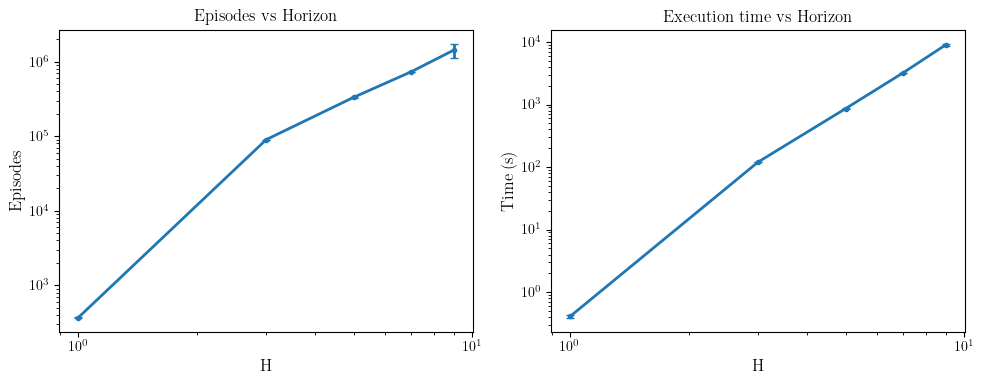

Saved plot to /Users/angel/Desktop/prism-games/prism-examples/csgs/learning/analysis/../results/H/safe_risky4/safe_risky_H_complexity.pdf


In [209]:
fig, axes = plt.subplots(1, 2, figsize=(3,5))

# --- Episodes vs H ---
axes[0].errorbar(res_df["H"], res_df["episodes"], yerr=res_df["episodes_std"], 
                 marker='o', markersize=3, capsize=3)
axes[0].set_xlabel("H")
axes[0].set_ylabel("Episodes")
axes[0].set_title("Episodes vs Horizon")
axes[0].set_xscale("log")
axes[0].set_yscale("log")


# --- Time & Samples vs H ---
ax1 = axes[1]

# Time (left axis)
ax1.errorbar(res_df["H"], res_df["time"], yerr=res_df["time_std"], 
             marker='o', markersize=3, capsize=3, label="Time (s)")
             # , color="tab:blue")
ax1.set_xlabel("H")
ax1.set_ylabel("Time (s)") #, color="tab:blue")
ax1.tick_params(axis='y') # , labelcolor="tab:blue")
ax1.set_title("Execution time vs Horizon")

# Samples (right axis)
# ax2 = ax1.twinx()
# ax2.errorbar(res_df["H"], res_df["samples_mean"], yerr=res_df["samples_std"], 
#              marker='s', markersize=3, capsize=3, label="Samples", color="tab:orange")
# ax2.set_ylabel("Total samples", color="tab:orange")
# ax2.tick_params(axis='y', labelcolor="tab:orange")

# Combine legends
# lines_1, labels_1 = ax1.get_legend_handles_labels()
# lines_2, labels_2 = ax2.get_legend_handles_labels()
# ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="best")

axes[1].set_xscale("log")
axes[1].set_yscale("log")

plt.tight_layout()

# --- Save ---
output_path = Path(RESULTS_DIR) / "safe_risky_H_complexity.pdf"
plt.savefig(output_path)

plt.show()
plt.close()

print(f"Saved plot to {output_path}")

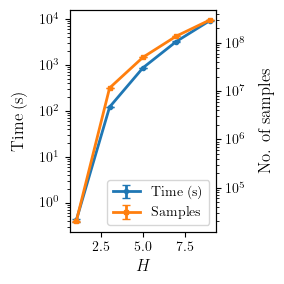

Saved plot to /Users/angel/Desktop/prism-games/prism-examples/csgs/learning/analysis/../results/H/safe_risky4/safe_risky4_H_complexity.pdf


In [225]:
fig, ax1 = plt.subplots(figsize=(3,3))

# --- Time (left axis) ---
ax1.errorbar(res_df["H"], res_df["time"], yerr=res_df["time_std"], 
             marker='o', markersize=3, capsize=3, label="Time (s)")
ax1.set_xlabel(r"$H$")
ax1.set_ylabel("Time (s)", labelpad=10)
# ax1.set_title("Execution Time & Episodes vs Horizon")

# --- Episodes (right axis) ---
ax2 = ax1.twinx()
ax2.errorbar(res_df["H"], res_df["samples"], yerr=res_df["samples_std"], 
             marker='s', markersize=3, capsize=3, label="Samples", color="tab:orange")
ax2.set_ylabel("No. of samples", labelpad=10)

# --- Log scales ---
# ax1.set_xscale("log")
ax1.set_yscale("log")
ax2.set_yscale("log")

# --- Combine legends ---
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="best")

plt.tight_layout()

# --- Save ---
output_path = Path(RESULTS_DIR) / "safe_risky4_H_complexity.pdf"
plt.savefig(output_path)

plt.show()
plt.close()

print(f"Saved plot to {output_path}")

- episode vs. H: polynomial + constants might dominate for small H
- execution time vs. H: looks more expensive
  - number of samples increase per episode (each of length H) -> per-episode cost $\approx H\cdot N^\omega_t$

## Complexity in $\varepsilon$

In [217]:
LOGS_DIR = os.getcwd() + "/../logs/H/safe_risky4"
LOGS_DIR

'/Users/angel/Desktop/prism-games/prism-examples/csgs/learning/analysis/../logs/H/safe_risky4'

In [218]:
log_df = pd.read_csv(Path(LOGS_DIR) / "safe_risky3.csv")
log_df

,episode,deltaT,maxRadius,avgRadius,numUnknownSlots,propUnknown,numSamples,totalNumSamples
0,1,9.000000,2.000000,1.564020,16,1.00,71,71
1,11,3.822370,0.805484,0.472673,16,1.00,138,1255
2,21,2.501533,0.544086,0.331920,16,1.00,158,2752
3,31,2.046098,0.446378,0.269625,16,1.00,170,4401
4,41,1.705868,0.374389,0.232067,16,1.00,179,6151
...,...,...,...,...,...,...,...,...
9016,90161,0.050011,0.011113,0.006957,4,0.25,107,11613332
9017,90171,0.050009,0.011113,0.006957,4,0.25,107,11614402
9018,90181,0.050006,0.011113,0.006956,4,0.25,107,11615472
9019,90191,0.050004,0.011112,0.006956,4,0.25,107,11616542


In [219]:
def process_log():
    log_df["numSamples"] = pd.to_numeric(log_df["numSamples"], errors="coerce").fillna(0)
    log_df["deltaT"] = pd.to_numeric(log_df["deltaT"], errors="coerce").fillna(0)
    # --- Compute epsilon ---
    log_df["epsilon"] = log_df["deltaT"] / 4.0
    # --- Compute cumulative samples ---
    if "totalNumSamples" in log_df.columns:
        log_df["cumSamples"] = pd.to_numeric(log_df["totalNumSamples"], errors="coerce").fillna(0)
    else:
        log_df["cumSamples"] = log_df["numSamples"].cumsum()
    
    log_df = log_df.sort_values("epsilon")

In [220]:
log_df

,episode,deltaT,maxRadius,avgRadius,numUnknownSlots,propUnknown,numSamples,totalNumSamples,epsilon,cumSamples
9020,90201,0.050002,0.011111,0.006956,4,0.25,107,11617612,0.012500,11617612
9019,90191,0.050004,0.011112,0.006956,4,0.25,107,11616542,0.012501,11616542
9018,90181,0.050006,0.011113,0.006956,4,0.25,107,11615472,0.012502,11615472
9017,90171,0.050009,0.011113,0.006957,4,0.25,107,11614402,0.012502,11614402
9016,90161,0.050011,0.011113,0.006957,4,0.25,107,11613332,0.012503,11613332
...,...,...,...,...,...,...,...,...,...,...
4,41,1.705868,0.374389,0.232067,16,1.00,179,6151,0.426467,6151
3,31,2.046098,0.446378,0.269625,16,1.00,170,4401,0.511525,4401
2,21,2.501533,0.544086,0.331920,16,1.00,158,2752,0.625383,2752
1,11,3.822370,0.805484,0.472673,16,1.00,138,1255,0.955592,1255


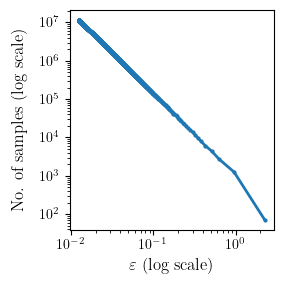

In [227]:
plt.figure(figsize=(3,3))
plt.plot(log_df["epsilon"], log_df["cumSamples"], marker='o', markersize=2)

plt.xlabel(r"$\varepsilon$ (log scale)")
plt.ylabel("No. of samples (log scale)", labelpad=10)
# plt.title("Sample complexity vs ε")

plt.xscale("log")
plt.yscale("log")

plt.tight_layout()

output_path = Path(RESULTS_DIR) / "safe_risky4_3_eps_complexity.pdf"
plt.savefig(output_path)

plt.show()
plt.close()